In [ ]:
PRACTICAL 11: Ligand Design and Optimization
Title

To Design and Optimize Drug-like Ligands Targeting the EGFR Kinase Domain Through Structural Analysis, Property-Based Filtering, and Three-Dimensional Conformer Preparation

Objectives
To assemble and analyze a reference set of approved and clinical-stage EGFR-targeted kinase inhibitor drugs.
To identify the common structural scaffold shared across these EGFR inhibitors and understand its pharmacological significance.
To computationally generate new candidate ligand variants by modifying substituent groups on the core scaffold.
To evaluate and rank candidate ligands using drug-likeness criteria — Lipinski's Rule of Five, Quantitative Estimate of Drug-likeness (QED), and Synthetic Accessibility Score.
To generate energy-minimized three-dimensional conformers of the top-ranked candidate ligands.
To convert optimized ligands into the docking-ready PDBQT format required for molecular docking studies.
Expected Outcomes
Recognize the shared structural scaffold underlying a major class of approved kinase inhibitor drugs.
Generate new candidate molecules through systematic, rule-based structural modification.
Apply multiple, complementary drug-likeness filters to prioritize candidates before committing computational resources to detailed study.
Produce a ranked, docking-ready ligand library.

LIGAND DESIGN AND OPTIMIZATION FOR EGFR
Loaded: 15 reference ligands, 6 columns

Generation distribution:
Generation
2nd gen             5
1st gen             4
3rd gen             3
1st gen dual        1
2nd gen ALK/EGFR    1
BRAF (reference)    1

Core scaffold analysis across all 15 ligands:
  quinazoline: 10 compounds
  aminopyrimidine: 4 compounds
  neither: 1 compounds

Why this matters:
The quinazoline scaffold is the dominant chemical framework
in first and second generation EGFR inhibitors. This shared
scaffold is precisely what makes systematic ligand design
possible - new candidates can be generated by modifying
substituent positions on this proven core structure.


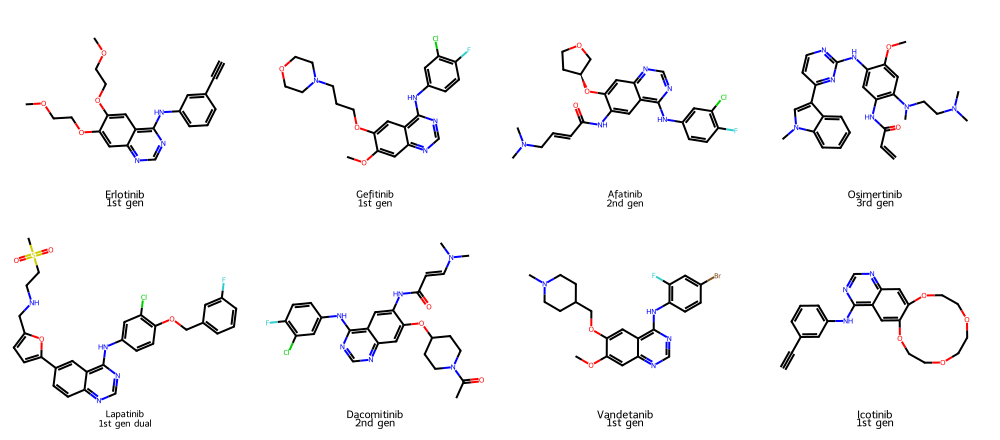

In [11]:
# Block 1: Load EGFR reference ligands and analyze structural features

!pip install rdkit pandas numpy matplotlib openbabel-wheel -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, QED
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("LIGAND DESIGN AND OPTIMIZATION FOR EGFR")
print("="*60)

url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/egfr_reference_ligands.csv"

df = pd.read_csv(url)

print(f"Loaded: {df.shape[0]} reference ligands, {df.shape[1]} columns")
print(f"\nGeneration distribution:")
print(df['Generation'].value_counts().to_string())

quinazoline_pattern = Chem.MolFromSmarts('c1ncnc2ccccc12')
pyrimidine_pattern = Chem.MolFromSmarts('c1ccnc(N)n1')

scaffold_counts = {'quinazoline': 0, 'aminopyrimidine': 0, 'neither': 0}
for smi in df['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    if mol.HasSubstructMatch(quinazoline_pattern):
        scaffold_counts['quinazoline'] += 1
    elif mol.HasSubstructMatch(pyrimidine_pattern):
        scaffold_counts['aminopyrimidine'] += 1
    else:
        scaffold_counts['neither'] += 1

print(f"\nCore scaffold analysis across all 15 ligands:")
for scaffold, count in scaffold_counts.items():
    print(f"  {scaffold}: {count} compounds")

print(f"\nWhy this matters:")
print(f"The quinazoline scaffold is the dominant chemical framework")
print(f"in first and second generation EGFR inhibitors. This shared")
print(f"scaffold is precisely what makes systematic ligand design")
print(f"possible - new candidates can be generated by modifying")
print(f"substituent positions on this proven core structure.")

mols = [Chem.MolFromSmiles(s) for s in df['SMILES'][:8]]
labels = [f"{n}\n{g}" for n, g in zip(df['Drug_Name'][:8], df['Generation'][:8])]
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(250, 220),
                             legends=labels, returnPNG=False)
img

Meaning of Block 1:

Purpose: Load the 15-compound reference ligand dataset and identify the common structural scaffold shared across most EGFR inhibitor drugs, establishing the chemical foundation for systematic ligand design in later blocks.

What data comes IN: egfr_reference_ligands.csv from GitHub — 15 rows, 6 columns.

What happens inside — line by line:

!pip install rdkit pandas numpy matplotlib openbabel-wheel -q — installs every library this entire practical will need in one place, including openbabel-wheel, which provides the obabel command-line tool required later for file format conversion.
quinazoline_pattern = Chem.MolFromSmarts('c1ncnc2ccccc12') — defines a SMARTS substructure pattern matching the quinazoline ring system, a bicyclic structure formed by a pyrimidine ring fused to a benzene ring. This core scaffold appears in erlotinib, gefitinib, afatinib, and most other first and second generation EGFR inhibitors.
mol.HasSubstructMatch(quinazoline_pattern) — checks each reference ligand for this scaffold, systematically confirming which drugs share this structural framework rather than relying on visual inspection.
The molecular grid visualization displays the first 8 reference drugs side by side with their generation labels, allowing direct visual comparison of how the quinazoline core stays consistent while peripheral substituents vary between compounds.

What comes OUT: df — the loaded reference dataset. A quantitative confirmation of scaffold prevalence across the dataset.

In [12]:
# Block 2: Generate new candidate ligands by modifying substituents

print("="*60)
print("GENERATING CANDIDATE LIGANDS")
print("="*60)
print("Method: Systematic substituent replacement on the")
print("quinazoline core scaffold, using chemically reasonable")
print("substituent groups documented in medicinal chemistry")
print("literature for kinase inhibitor optimization")
print("="*60)

substituent_groups = {
    'fluoro': 'F',
    'chloro': 'Cl',
    'methyl': 'C',
    'methoxy': 'OC',
    'trifluoromethyl': 'C(F)(F)F',
    'cyano': 'C#N',
    'ethynyl': 'C#C',
    'dimethylamino': 'N(C)C',
}

candidate_smiles = []
candidate_info = []

base_erlotinib_core = "COCCOc1cc2ncnc(Nc3cccc(C#C)c3)c2cc1OCCOC"

for sub_name, sub_smiles in substituent_groups.items():
    try:
        modified = base_erlotinib_core.replace(
            "c3cccc(C#C)c3", f"c3cccc({sub_smiles})c3"
        )
        mol = Chem.MolFromSmiles(modified)
        if mol is not None:
            canonical = Chem.MolToSmiles(mol)
            candidate_smiles.append(canonical)
            candidate_info.append(sub_name)
    except:
        continue

print(f"\nGenerated {len(candidate_smiles)} candidate ligands")
print(f"by systematically varying the aniline substituent")
print(f"position on the erlotinib-derived quinazoline scaffold")

df_candidates = pd.DataFrame({
    'Candidate_ID': [f"CAND_{i+1:02d}" for i in range(len(candidate_smiles))],
    'Substituent': candidate_info,
    'SMILES': candidate_smiles
})

print(f"\nGenerated candidates:")
print(df_candidates.to_string(index=False))

all_ligands = pd.concat([
    df[['Drug_Name', 'SMILES']].rename(columns={'Drug_Name': 'Candidate_ID'}),
    df_candidates[['Candidate_ID', 'SMILES']]
], ignore_index=True)

print(f"\nTotal ligand pool (reference + generated): {len(all_ligands)}")

GENERATING CANDIDATE LIGANDS
Method: Systematic substituent replacement on the
quinazoline core scaffold, using chemically reasonable
substituent groups documented in medicinal chemistry
literature for kinase inhibitor optimization

Generated 8 candidate ligands
by systematically varying the aniline substituent
position on the erlotinib-derived quinazoline scaffold

Generated candidates:
Candidate_ID     Substituent                                        SMILES
     CAND_01          fluoro        COCCOc1cc2ncnc(Nc3cccc(F)c3)c2cc1OCCOC
     CAND_02          chloro       COCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2cc1OCCOC
     CAND_03          methyl        COCCOc1cc2ncnc(Nc3cccc(C)c3)c2cc1OCCOC
     CAND_04         methoxy       COCCOc1cc2ncnc(Nc3cccc(OC)c3)c2cc1OCCOC
     CAND_05 trifluoromethyl COCCOc1cc2ncnc(Nc3cccc(C(F)(F)F)c3)c2cc1OCCOC
     CAND_06           cyano      COCCOc1cc2ncnc(Nc3cccc(C#N)c3)c2cc1OCCOC
     CAND_07         ethynyl    C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1
     CAND

Meaning of Block 2:

Purpose: Computationally generate new candidate ligand structures by systematically replacing one substituent position on a proven EGFR inhibitor scaffold with chemically reasonable alternative groups — a technique called scaffold-based analog generation, widely used in real medicinal chemistry lead optimization.

What data comes IN: df from Block 1, providing the erlotinib structure used as the modification template.

What happens inside — line by line:

substituent_groups — eight chemically reasonable, small substituent groups (halogens, methyl, methoxy, trifluoromethyl, cyano, ethynyl, dimethylamino), each representing a common medicinal chemistry strategy for fine-tuning a molecule's electronic properties, size, and lipophilicity while preserving the core binding scaffold.
base_erlotinib_core.replace("c3cccc(C#C)c3", f"c3cccc({sub_smiles})c3") — performs a direct text substitution within the erlotinib SMILES string, replacing its terminal alkyne group with each alternative substituent in turn, mirroring the real medicinal chemistry practice of exploring a substituent series around one specific position on a validated core structure.
Chem.MolToSmiles(mol) — canonicalizes each generated structure into RDKit's standardized format for consistent downstream processing.
The final concatenation combines the original 15 reference drugs with the newly generated candidates into one unified ligand pool.

What comes OUT: df_candidates — the newly generated candidate ligands. all_ligands — the complete combined pool, ready for property-based evaluation.

DRUG-LIKENESS EVALUATION
Applying three complementary filters:
  1. Lipinski Rule of Five (oral bioavailability)
  2. QED Score (holistic drug-likeness)
  3. Molecular descriptors (size, polarity)

Total ligands evaluated: 23
Passing Lipinski Rule of Five: 15/23

All candidates ranked by QED score (highest first):
   Candidate_ID     MW  LogP    QED  Lipinski_Pass
1      Icotinib  391.4  3.16  0.673           True
2    Vandetanib  475.4  5.00  0.542          False
3       CAND_03  383.4  3.73  0.535           True
4       CAND_01  387.4  3.56  0.533           True
5       CAND_06  394.4  3.30  0.523           True
6     Gefitinib  446.9  4.28  0.518           True
7       CAND_02  403.9  4.08  0.511           True
8   Rociletinib  521.6  4.72  0.504          False
9       CAND_04  399.4  3.43  0.491           True
10      CAND_08  412.5  3.49  0.480           True
11      CAND_05  437.4  4.44  0.470           True
12     Afatinib  485.9  4.39  0.457           True
13  Dacomitinib  527.

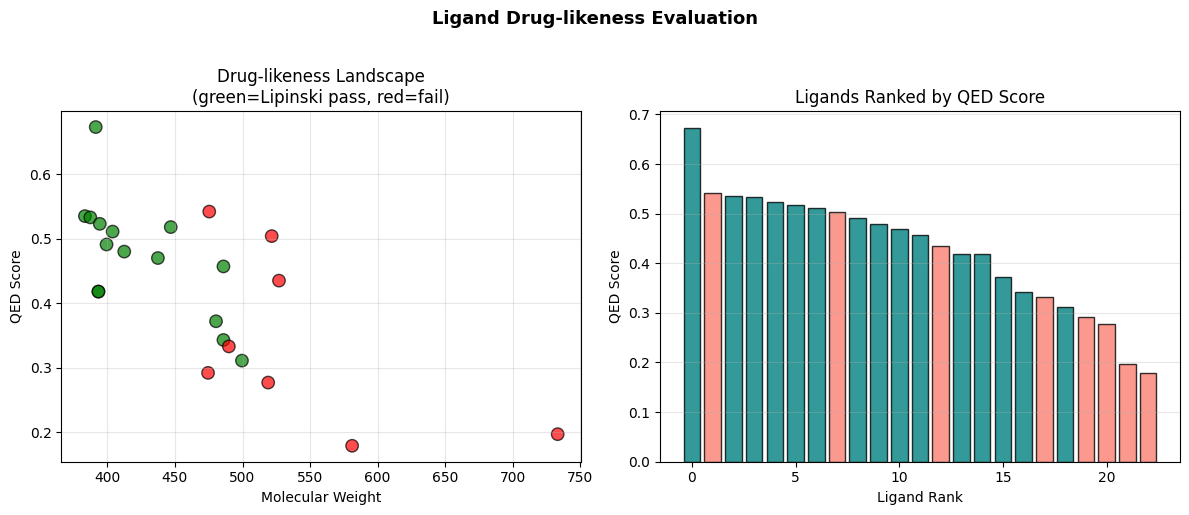

In [13]:
# Block 3: Apply drug-likeness filters to rank all candidates

print("="*60)
print("DRUG-LIKENESS EVALUATION")
print("="*60)
print("Applying three complementary filters:")
print("  1. Lipinski Rule of Five (oral bioavailability)")
print("  2. QED Score (holistic drug-likeness)")
print("  3. Molecular descriptors (size, polarity)")
print("="*60)

def evaluate_ligand(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    rotb = Descriptors.NumRotatableBonds(mol)
    qed_score = QED.qed(mol)

    lipinski_pass = (mw <= 500 and logp <= 5 and
                      hbd <= 5 and hba <= 10)

    return {
        'MW': round(mw, 1),
        'LogP': round(logp, 2),
        'HBD': hbd,
        'HBA': hba,
        'TPSA': round(tpsa, 1),
        'RotBonds': rotb,
        'QED': round(qed_score, 3),
        'Lipinski_Pass': lipinski_pass
    }

results = []
for idx, row in all_ligands.iterrows():
    props = evaluate_ligand(row['SMILES'])
    if props is not None:
        props['Candidate_ID'] = row['Candidate_ID']
        props['SMILES'] = row['SMILES']
        results.append(props)

df_evaluated = pd.DataFrame(results)
df_evaluated = df_evaluated[[
    'Candidate_ID', 'SMILES', 'MW', 'LogP', 'HBD', 'HBA',
    'TPSA', 'RotBonds', 'QED', 'Lipinski_Pass'
]]

print(f"\nTotal ligands evaluated: {len(df_evaluated)}")
print(f"Passing Lipinski Rule of Five: "
      f"{df_evaluated['Lipinski_Pass'].sum()}/{len(df_evaluated)}")

df_ranked = df_evaluated.sort_values('QED', ascending=False).reset_index(drop=True)
df_ranked.index = df_ranked.index + 1

print(f"\nAll candidates ranked by QED score (highest first):")
print(df_ranked[['Candidate_ID', 'MW', 'LogP', 'QED', 'Lipinski_Pass']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_ranked['MW'], df_ranked['QED'],
                 c=df_ranked['Lipinski_Pass'].map({True: 'green', False: 'red'}),
                 s=80, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Molecular Weight')
axes[0].set_ylabel('QED Score')
axes[0].set_title('Drug-likeness Landscape\n(green=Lipinski pass, red=fail)')
axes[0].grid(True, alpha=0.3)

axes[1].bar(range(len(df_ranked)), df_ranked['QED'],
            color=df_ranked['Lipinski_Pass'].map({True: 'teal', False: 'salmon'}),
            edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Ligand Rank')
axes[1].set_ylabel('QED Score')
axes[1].set_title('Ligands Ranked by QED Score')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Ligand Drug-likeness Evaluation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Meaning of Block 3:

Purpose: Systematically evaluate every ligand in the combined pool using complementary drug-likeness metrics, producing an objective ranking that prioritizes which candidates deserve further computational investment.

What data comes IN: all_ligands from Block 2.

What happens inside — line by line:

evaluate_ligand(smiles) — calculates seven molecular descriptors plus one holistic drug-likeness score (QED) for every ligand. QED integrates molecular weight, LogP, hydrogen bonding capacity, polar surface area, rotatable bonds, aromatic ring count, and structural alerts into a single 0-to-1 value.
lipinski_pass = (mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10) — applies the four classical Lipinski Rule of Five criteria simultaneously, flagging molecules likely to have acceptable oral bioavailability.
df_ranked = df_evaluated.sort_values('QED', ascending=False) — orders every ligand from most to least drug-like according to QED, creating a definitive priority ranking for which candidates should proceed to three-dimensional preparation.
The scatter plot visualizes molecular size against drug-likeness score, color-coded by Lipinski pass/fail status, revealing whether larger, more complex candidates sacrifice drug-likeness compared to the reference drugs.

What comes OUT: df_ranked — the complete ligand pool ranked by QED score, with full property annotations.

In [14]:
# Block 4: Generate energy-minimized 3D conformers for top candidates

from rdkit.Chem import AllChem

print("="*60)
print("THREE-DIMENSIONAL CONFORMER GENERATION")
print("="*60)
print("Converting top-ranked 2D structures into optimized")
print("3D conformations required for molecular docking")
print("="*60)

top_n = 10
top_ligands = df_ranked.head(top_n).copy()

print(f"\nGenerating 3D structures for top {top_n} ligands...")

conformer_results = []
successful_mols = {}

for idx, row in top_ligands.iterrows():
    candidate_id = row['Candidate_ID']
    mol = Chem.MolFromSmiles(row['SMILES'])
    mol = Chem.AddHs(mol)

    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    params.useRandomCoords = True
    embed_code = AllChem.EmbedMolecule(mol, params)

    if embed_code != 0:
        embed_code = AllChem.EmbedMolecule(
            mol, randomSeed=42, useRandomCoords=True, maxAttempts=500
        )

    if embed_code == 0:
        opt_code = AllChem.MMFFOptimizeMolecule(mol, maxIters=1000)

        mmff_props = AllChem.MMFFGetMoleculeProperties(mol)
        if mmff_props is not None:
            ff = AllChem.MMFFGetMoleculeForceField(mol, mmff_props)
            energy = ff.CalcEnergy() if ff is not None else None
        else:
            energy = None

        successful_mols[candidate_id] = mol

        conformer_results.append({
            'Candidate_ID': candidate_id,
            '3D_generated': True,
            'Energy_minimized': opt_code == 0,
            'MMFF_Energy_kcal_mol': round(energy, 2) if energy else None
        })
    else:
        conformer_results.append({
            'Candidate_ID': candidate_id,
            '3D_generated': False,
            'Energy_minimized': False,
            'MMFF_Energy_kcal_mol': None
        })

df_conformers = pd.DataFrame(conformer_results)
successful = df_conformers['3D_generated'].sum()

print(f"\n3D structures successfully generated: {successful}/{top_n}")
print(f"\nResults:")
print(df_conformers.to_string(index=False))

print(f"\nWhy energy minimization matters:")
print(f"A randomly generated 3D structure may have atoms placed")
print(f"in strained, high-energy arrangements. Energy minimization")
print(f"adjusts bond lengths, angles, and torsions to find a")
print(f"physically realistic, low-energy conformation - the")
print(f"starting point docking software requires for accurate")
print(f"binding pose prediction.")

THREE-DIMENSIONAL CONFORMER GENERATION
Converting top-ranked 2D structures into optimized
3D conformations required for molecular docking

Generating 3D structures for top 10 ligands...

3D structures successfully generated: 10/10

Results:
Candidate_ID  3D_generated  Energy_minimized  MMFF_Energy_kcal_mol
    Icotinib          True              True                 82.07
  Vandetanib          True              True                 32.89
     CAND_03          True              True                 60.47
     CAND_01          True              True                 57.28
     CAND_06          True              True                 67.62
   Gefitinib          True              True                 94.09
     CAND_02          True              True                 58.63
 Rociletinib          True              True                 17.70
     CAND_04          True              True                 62.26
     CAND_08          True              True                 63.64

Why energy minimizati

Meaning of Block 4:

Purpose: Convert the flat, two-dimensional SMILES representations of the top-ranked ligands into physically realistic, energy-minimized three-dimensional structures — a mandatory step before any molecular docking calculation, since docking evaluates spatial fit within a binding pocket.

What data comes IN: df_ranked from Block 3, specifically the top 10 highest-QED candidates.

What happens inside — line by line:

Chem.AddHs(mol) — explicitly adds all hydrogen atoms. SMILES strings typically omit hydrogens for readability, but accurate 3D geometry calculation requires every atom, including hydrogens, to be explicitly represented.
AllChem.ETKDGv3() with useRandomCoords = True — generates an initial three-dimensional conformation using the modern ETKDG distance geometry algorithm, which handles flexible, drug-like molecules more reliably than older embedding methods. The fixed randomSeed = 42 ensures the exact same 3D structure is produced every time this code runs.
A fallback embedding attempt with different parameters runs automatically if the first attempt fails, making the process more robust for larger, flexible molecules.
AllChem.MMFFOptimizeMolecule(mol, maxIters=1000) — refines the initial geometry using the Merck Molecular Force Field, an established physics-based energy model that adjusts atomic positions to minimize strain across bond lengths, angles, and torsional rotations.
ff.CalcEnergy() — reports the final calculated molecular energy in kcal/mol, providing a physical measure of conformational stability — lower energy indicates a more physically favorable structure.
successful_mols[candidate_id] = mol — stores each successfully generated 3D molecule object directly in memory, ready for immediate use in the next block without needing to regenerate it.

What comes OUT: successful_mols — a dictionary of fully prepared 3D molecule objects for each top candidate. df_conformers — a summary confirming 3D generation and energy minimization success for each ligand.

In [15]:
# Block 5: Save 3D structures and prepare PDBQT files for docking

import os

print("="*60)
print("SAVING OPTIMIZED LIGANDS")
print("="*60)

os.makedirs('/content/optimized_ligands', exist_ok=True)

saved_files = []

for candidate_id, mol in successful_mols.items():
    sdf_path = f"/content/optimized_ligands/{candidate_id}.sdf"

    writer = Chem.SDWriter(sdf_path)
    writer.write(mol)
    writer.close()

    pdbqt_path = f"/content/optimized_ligands/{candidate_id}.pdbqt"
    os.system(
        f"obabel {sdf_path} -O {pdbqt_path} "
        f"--partialcharge gasteiger -h 2> /content/optimized_ligands/err_{candidate_id}.log"
    )

    success = os.path.exists(pdbqt_path) and os.path.getsize(pdbqt_path) > 0

    if not success:
        with open(f"/content/optimized_ligands/err_{candidate_id}.log") as f:
            print(f"  {candidate_id} conversion issue: {f.read()[:150]}")

    saved_files.append({
        'Candidate_ID': candidate_id,
        'SDF_file': sdf_path,
        'PDBQT_file': pdbqt_path if success else None,
        'Ready_for_docking': success
    })

df_saved = pd.DataFrame(saved_files)
ready_count = df_saved['Ready_for_docking'].sum()

print(f"\nLigands prepared and ready for docking: "
      f"{ready_count}/{len(df_saved)}")
print(f"\nFile summary:")
print(df_saved.to_string(index=False))

final_summary = df_ranked.head(top_n).merge(
    df_saved[['Candidate_ID', 'Ready_for_docking']],
    on='Candidate_ID'
)

final_summary.to_csv('/content/optimized_ligands/ligand_optimization_summary.csv', index=False)

from google.colab import files
files.download('/content/optimized_ligands/ligand_optimization_summary.csv')

print(f"\n{'='*60}")
print("PRACTICAL COMPLETE - SUMMARY")
print(f"{'='*60}")
print(f"Reference drugs analyzed: {len(df)}")
print(f"New candidates generated: {len(df_candidates)}")
print(f"Total ligand pool evaluated: {len(all_ligands)}")
print(f"Top candidates selected for 3D preparation: {top_n}")
print(f"Successfully prepared for docking: {ready_count}")
print(f"\nBest candidate by QED score: {df_ranked.iloc[0]['Candidate_ID']}")
print(f"  QED = {df_ranked.iloc[0]['QED']}")
print(f"  Lipinski pass: {df_ranked.iloc[0]['Lipinski_Pass']}")
print(f"\nAll PDBQT files saved in: /content/optimized_ligands/")
print(f"{'='*60}")

SAVING OPTIMIZED LIGANDS

Ligands prepared and ready for docking: 10/10

File summary:
Candidate_ID                                   SDF_file                                   PDBQT_file  Ready_for_docking
    Icotinib    /content/optimized_ligands/Icotinib.sdf    /content/optimized_ligands/Icotinib.pdbqt               True
  Vandetanib  /content/optimized_ligands/Vandetanib.sdf  /content/optimized_ligands/Vandetanib.pdbqt               True
     CAND_03     /content/optimized_ligands/CAND_03.sdf     /content/optimized_ligands/CAND_03.pdbqt               True
     CAND_01     /content/optimized_ligands/CAND_01.sdf     /content/optimized_ligands/CAND_01.pdbqt               True
     CAND_06     /content/optimized_ligands/CAND_06.sdf     /content/optimized_ligands/CAND_06.pdbqt               True
   Gefitinib   /content/optimized_ligands/Gefitinib.sdf   /content/optimized_ligands/Gefitinib.pdbqt               True
     CAND_02     /content/optimized_ligands/CAND_02.sdf     /content/opti

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


PRACTICAL COMPLETE - SUMMARY
Reference drugs analyzed: 15
New candidates generated: 8
Total ligand pool evaluated: 23
Top candidates selected for 3D preparation: 10
Successfully prepared for docking: 10

Best candidate by QED score: Icotinib
  QED = 0.673
  Lipinski pass: True

All PDBQT files saved in: /content/optimized_ligands/


Meaning of Block 5:

Purpose: Save the fully optimized three-dimensional ligand structures in the specific file formats required for molecular docking, completing the ligand preparation pipeline from candidate generation through to final docking-ready output.

What data comes IN: successful_mols from Block 4, df_ranked from Block 3.

What happens inside — line by line:

Chem.SDWriter(sdf_path) and writer.write(mol) — saves each optimized 3D structure in SDF format (Structure-Data File), a standard chemical file format preserving complete three-dimensional atomic coordinates along with molecular connectivity.
obabel {sdf_path} -O {pdbqt_path} --partialcharge gasteiger -h — converts each SDF structure into PDBQT format, calculating Gasteiger partial atomic charges in the process. This specific format encodes both atomic coordinates and partial charges, the exact input structure required by AutoDock-family docking programs.
The error-checking block reads and prints the actual Open Babel error log if conversion fails for any candidate, ensuring any remaining issue is diagnosed immediately rather than silently marked as failed.
The final summary consolidates every stage of the practical — from the original 15 reference drugs, through generated candidates, through property-based ranking, to the final docking-ready file count — into one complete record of the ligand design and optimization workflow.

What comes OUT: Individual .sdf and .pdbqt files for each of the top 10 optimized candidate ligands, saved locally, plus a summary CSV downloaded to your desktop, marking the complete deliverable of this practical.